In [1]:
#Total mensual de viajeros internacionales
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller

import tensorflow as tf
from sklearn.preprocessing import StandardScaler
from keras.models import Sequential, save_model, load_model
from keras.layers import Dense, LSTM, Dropout
from keras.callbacks import EarlyStopping
from keras.metrics import MeanSquaredError, RootMeanSquaredError
from keras.optimizers import Adam
from sklearn.metrics import mean_squared_error, mean_absolute_error
import keras

In [2]:
df = pd.read_csv("./df/Base_Migracion_2009-2026jun.csv")

df['Viajero'] = pd.to_numeric(df['Viajero'], errors='coerce')

# Subconjunto consistente para todo el período 2009-2026
# entre 2022-2023 la categoría 'Viajero' excluyó viajeros no turísticos de alta frecuencia
# (comercio fronterizo, tránsito), por lo que solo Turista + Excursionista son comparables
df_te = df[df['Tipo de Viajero'].isin(['Turista', 'Excursionista'])].copy()

print(f"Total filas: {len(df)}, Turista+Excursionista: {len(df_te)}")
df.head(3)

df_te = df[df['Tipo de Viajero'].isin(['Turista', 'Excursionista'])].copy()
df_te['Fecha'] = pd.to_datetime(df_te['Año'].astype(str) + '-' + df_te['Mes cod'].astype(str) + '-01')


Total filas: 161036, Turista+Excursionista: 137642


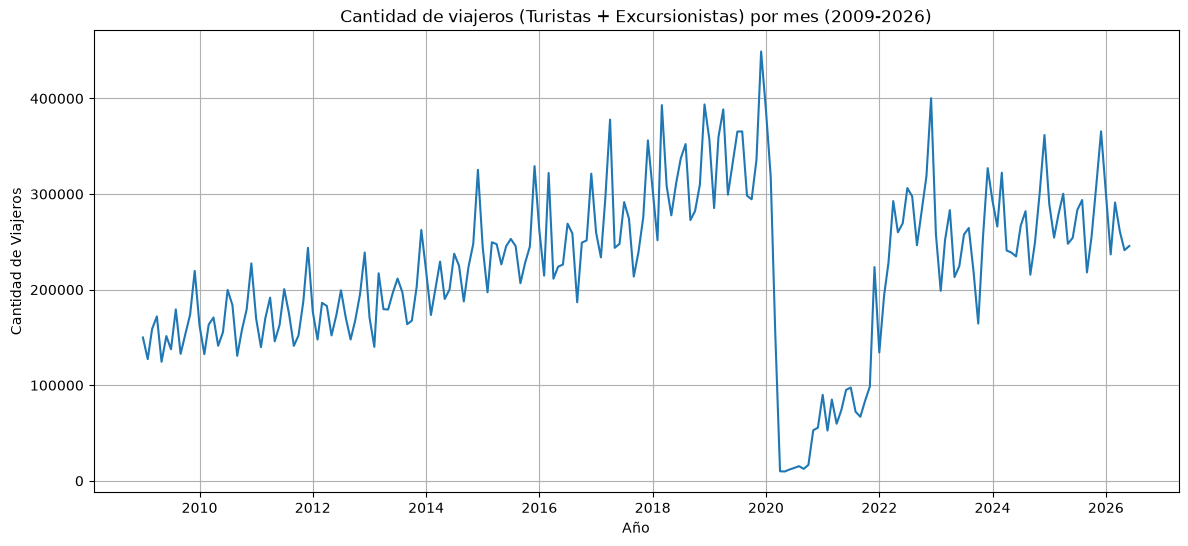

In [3]:
#VIAJEROS MENSUALES
viajeros_mensuales = df_te.groupby('Fecha')['Viajero'].sum().reset_index()
viajeros_mensuales.set_index('Fecha', inplace=True)

plt.figure(figsize=(14, 6))
plt.plot(viajeros_mensuales)
plt.gca().set(title="Cantidad de viajeros (Turistas + Excursionistas) por mes (2009-2026)", xlabel="Año", ylabel="Cantidad de Viajeros")
plt.grid(True)
plt.show()

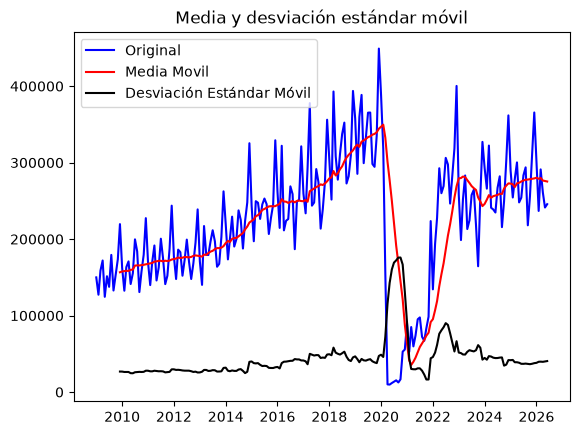

In [4]:
#media y desviacion estandar
mediaMovil = viajeros_mensuales.rolling(window=12).mean()
deMovil = viajeros_mensuales.rolling(window=12).std()

original = plt.plot(viajeros_mensuales, color="blue", label="Original")
media = plt.plot(mediaMovil, color='red', label = 'Media Movil')
ds = plt.plot(deMovil,color='black', label = 'Desviación Estándar Móvil')
plt.legend(loc = 'best')
plt.title('Media y desviación estándar móvil')
plt.show(block=False)

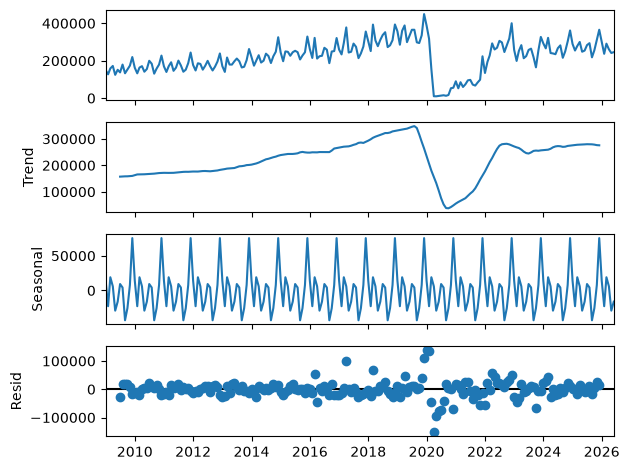

In [5]:
descomposicion = seasonal_decompose(viajeros_mensuales)
descomposicion.plot();

In [6]:
print("Test Dickey Fuller")
testDf = adfuller(viajeros_mensuales, autolag='AIC')
salidaDf = pd.Series(testDf[0:4], index=['Estadístico de prueba','p-value','No. retardos usados','No. observaciones usadas'])
for key, value in testDf[4].items():
    salidaDf['Critical Value (%s)' %key] = value
print(salidaDf)

Test Dickey Fuller
Estadístico de prueba        -2.886311
p-value                       0.046963
No. retardos usados          14.000000
No. observaciones usadas    195.000000
Critical Value (1%)          -3.464337
Critical Value (5%)          -2.876479
Critical Value (10%)         -2.574733
dtype: float64


p-value = 0.046963, menor a 0.05, es estacionaria por lo que no hay necesidad de diferenciar la serie.

In [7]:
#normalizar serie
scaler = StandardScaler()
serie_scaled = scaler.fit_transform(viajeros_mensuales.values.reshape(-1,1))
print("Datos normalizados: ")
print(serie_scaled[0:7].flatten())

Datos normalizados: 
[-0.85767986 -1.12554003 -0.75295514 -0.59657406 -1.15800656 -0.83994771
 -1.00352279]


In [8]:
#Division de datos para train y test
total_len = len(serie_scaled)
train_size = int(0.6 * total_len)
val_size = int(0.2 * total_len)
test_size = total_len - train_size - val_size

train = serie_scaled[0:train_size]
validation = serie_scaled[train_size:train_size+val_size]
test = serie_scaled[train_size+val_size:]

print(f"Entrenamiento: {len(train)}")
print(f"Validación: {len(validation)}")
print(f"Prueba: {len(test)}")

Entrenamiento: 126
Validación: 42
Prueba: 42


In [9]:
def make_secuencias(serie, retrasos=1):
    X, y = [], []
    for i in range(len(serie)-retrasos):
        X.append(serie[i:(i+retrasos), 0])
        y.append(serie[i+retrasos, 0])
    return np.array(X), np.array(y)
#seuencuas
n_pasos = 12 #meses
X_train, y_train = make_secuencias(train, n_pasos)
X_val, y_val = make_secuencias(validation, n_pasos)
X_test, y_test = make_secuencias(test, n_pasos)
print("=== Secuencias ===")
print(f"X_train shape: {X_train.shape}")
print(f"X_val shape: {X_val.shape}")
print(f"X_test shape: {X_test.shape}")

#redimension LTSM
X_train = X_train.reshape((X_train.shape[0], X_train.shape[1], 1)) #[muestras, pasos_tiempo, carac.]
X_val = X_val.reshape((X_val.shape[0], X_val.shape[1], 1))
X_test = X_test.reshape((X_test.shape[0], X_test.shape[1], 1))
print("=== Redimension ===")
print(f"X_train reshaped: {X_train.shape}")
print(f"X_val reshaped: {X_val.shape}")
print(f"X_test reshaped: {X_test.shape}")

=== Secuencias ===
X_train shape: (114, 12)
X_val shape: (30, 12)
X_test shape: (30, 12)
=== Redimension ===
X_train reshaped: (114, 12, 1)
X_val reshaped: (30, 12, 1)
X_test reshaped: (30, 12, 1)


### Modelo 1: LSTM Básico (TensorFlow/Keras)

Modelo 1 - Resumen:


/Users/hansellopez/Documents/Projects/DataScience2026/Labs_DataSci/Lab 2/.venv/lib/python3.12/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 50)             │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,451 (40.82 KB)

...

1/4 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.1860 - root_mean_squared_error: 0.4313

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.1733 - root_mean_squared_error: 0.4163 - val_loss: 34.4645 - val_root_mean_squared_error: 5.8706


Epoch 28/150


1/4 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.2050 - root_mean_squared_error: 0.4528

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.1727 - root_mean_squared_error: 0.4156 - val_loss: 41.3066 - val_root_mean_squared_error: 6.4270


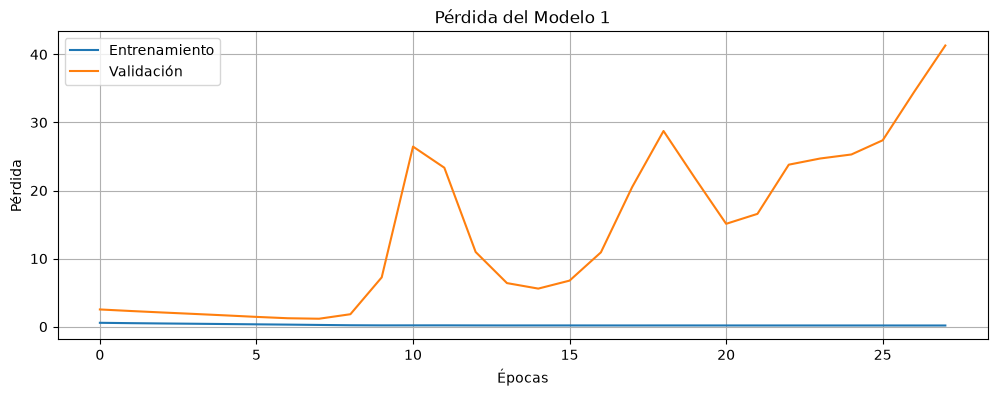

Evaluación del Modelo 1:
Entrenamiento:


Validación:


Prueba:


[0.22277088463306427, 0.4719861149787903]

In [10]:
modelo1 = Sequential([
    LSTM(50, activation='relu', input_shape=(n_pasos, 1)),
    Dense(1)
])

modelo1.compile(
    optimizer=Adam(learning_rate=0.001), 
    loss='mse',
    metrics=[RootMeanSquaredError()]
)
print("Modelo 1 - Resumen:")
modelo1.summary()

#Early stopping
early_stop = EarlyStopping(
    monitor='val_loss', 
    patience=20, 
    restore_best_weights=True
)

#train
history1 = modelo1.fit(
    X_train, y_train,
    epochs=150,
    batch_size=32,
    validation_data=(X_val, y_val),
    callbacks=[early_stop],
    verbose=1
)

#graficas
plt.figure(figsize=(12, 4))
plt.plot(history1.history['loss'], label='Entrenamiento')
plt.plot(history1.history['val_loss'], label='Validación')
plt.title('Pérdida del Modelo 1')
plt.xlabel('Épocas')
plt.ylabel('Pérdida')
plt.legend()
plt.grid(True)
plt.show()

#eval
print("Evaluación del Modelo 1:")
print("Entrenamiento:")
modelo1.evaluate(X_train, y_train, verbose=0)
print("Validación:")
modelo1.evaluate(X_val, y_val, verbose=0)
print("Prueba:")
modelo1.evaluate(X_test, y_test, verbose=0)

### Modelo 2: Mas complejidad

Modelo 2 - Resumen:


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_1 (LSTM)                   │ (None, 12, 100)        │        40,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 12, 100)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 12, 50)         │        30,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 12, 50)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 25)             │         7,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 25)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            26 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 78,626 (307.13 KB)

 Trainable params: 78,626 (307.13 KB)

...

1/8 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.1528 - root_mean_squared_error: 0.3909

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.1781 - root_mean_squared_error: 0.4221 - val_loss: 9.0173 - val_root_mean_squared_error: 3.0029


Epoch 23/150


1/8 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.1264 - root_mean_squared_error: 0.3555

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.1582 - root_mean_squared_error: 0.3978 - val_loss: 11.9151 - val_root_mean_squared_error: 3.4518


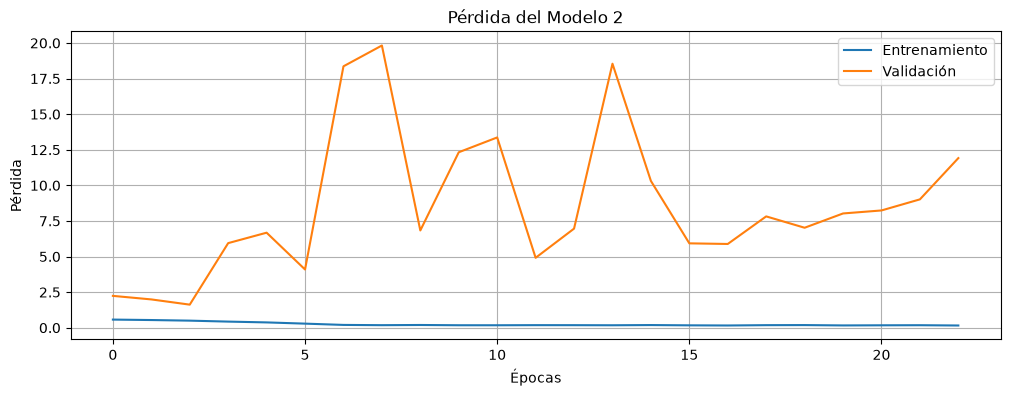

In [11]:
modelo2 = Sequential([
    LSTM(100, activation='relu', return_sequences=True, input_shape=(n_pasos, 1)),
    Dropout(0.2),
    LSTM(50, activation='relu', return_sequences=True),
    Dropout(0.2),
    LSTM(25, activation='relu'),
    Dropout(0.1),
    Dense(1)
])

modelo2.compile(
    optimizer=Adam(learning_rate=0.0005), 
    loss='mse',
    metrics=[RootMeanSquaredError()]
)
print("Modelo 2 - Resumen:")
modelo2.summary()

#train 2
history2 = modelo2.fit(
    X_train, y_train,
    epochs=150,
    batch_size=16,
    validation_data=(X_val, y_val),
    callbacks=[early_stop],
    verbose=1
)

#graficas 2
plt.figure(figsize=(12, 4))
plt.plot(history2.history['loss'], label='Entrenamiento')
plt.plot(history2.history['val_loss'], label='Validación')
plt.title('Pérdida del Modelo 2')
plt.xlabel('Épocas')
plt.ylabel('Pérdida')
plt.legend()
plt.grid(True)
plt.show()

In [12]:
#inversion transformacion y prediccion

def prediccion_desnormalizacion(modelo, X_data, scaler, serie_original, start_idx, n_pasos=1):
    #Predice y desnormaliza los datos para obtener valores en la escala original
    predicciones = []
    for X in X_data:
        X_reshaped = X.reshape((1, n_pasos, 1))
        y_pred_scaled = modelo.predict(X_reshaped, verbose=0)
        predicciones.append(y_pred_scaled[0, 0])
    
    predicciones = np.array(predicciones).reshape(-1, 1)
    predicciones_diff = scaler.inverse_transform(predicciones)
    
    #inversa diferenciacion
    predicciones_original = []
    for i, pred in enumerate(predicciones_diff):
        if i == 0:
            #1era prediccion, suma a valor anteririr en original
            idx = start_idx + n_pasos + i
            valor_anterior = serie_original.iloc[idx - 1]
        else:
            #sig, suma diferencia acumulada
            valor_anterior = predicciones_original[-1]
        predicciones_original.append(valor_anterior + pred[0])
    
    return np.array(predicciones_original)

### Predicciones

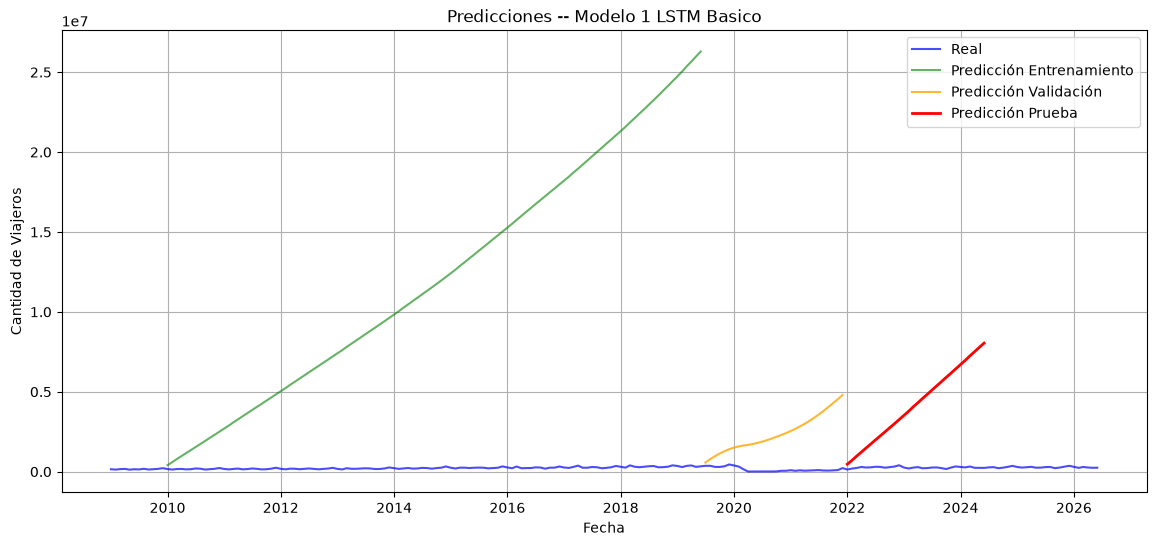

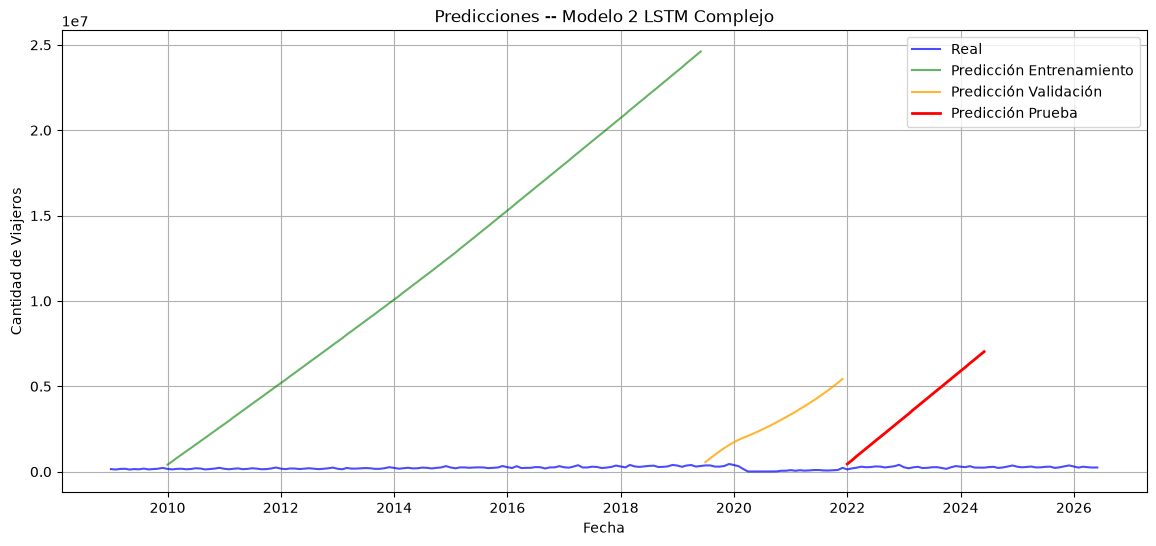

In [13]:
start_train = len(train) - n_pasos
start_val = start_train + len(validation) - n_pasos
start_test = start_val + len(test) - n_pasos

#predicciones modelo 1
pred_train1 = prediccion_desnormalizacion(modelo1, X_train, scaler, viajeros_mensuales, 0, n_pasos)
pred_val1 = prediccion_desnormalizacion(modelo1, X_val, scaler, viajeros_mensuales, start_train, n_pasos)
pred_test1 = prediccion_desnormalizacion(modelo1, X_test, scaler, viajeros_mensuales, start_val, n_pasos)

#predicciones modelo 2
pred_train2 = prediccion_desnormalizacion(modelo2, X_train, scaler, viajeros_mensuales, 0, n_pasos)
pred_val2 = prediccion_desnormalizacion(modelo2, X_val, scaler, viajeros_mensuales, start_train, n_pasos)
pred_test2 = prediccion_desnormalizacion(modelo2, X_test, scaler, viajeros_mensuales, start_val, n_pasos)


#graficas predicciones
def graficas(serie_original, pred_train, pred_val, pred_test, titulo):
    plt.figure(figsize=(14, 6))
    
    #Original
    plt.plot(serie_original.index, serie_original.values, label='Real', color='blue', alpha=0.7)
    #predicciones orignal
    train_idx = serie_original.index[n_pasos:n_pasos+len(pred_train)]
    val_idx = serie_original.index[start_train+n_pasos:start_train+n_pasos+len(pred_val)]
    test_idx = serie_original.index[start_val+n_pasos:start_val+n_pasos+len(pred_test)]
    
    plt.plot(train_idx, pred_train, label='Predicción Entrenamiento', color='green', alpha=0.6)
    plt.plot(val_idx, pred_val, label='Predicción Validación', color='orange', alpha=0.8)
    plt.plot(test_idx, pred_test, label='Predicción Prueba', color='red', linewidth=2)
    
    plt.title(titulo)
    plt.xlabel('Fecha')
    plt.ylabel('Cantidad de Viajeros')
    plt.legend()
    plt.grid(True)
    plt.show()

#graficas preudcciones modelo 1
graficas(
    viajeros_mensuales, 
    pred_train1, pred_val1, pred_test1,
    'Predicciones -- Modelo 1 LSTM Basico'
)

#grafiacs predicciones modelo 2
graficas(
    viajeros_mensuales, 
    pred_train2, pred_val2, pred_test2,
    'Predicciones -- Modelo 2 LSTM Complejo'
)

### Comparacion de modelos

In [14]:
def metricas(y_real, y_pred):
    rmse = np.sqrt(mean_squared_error(y_real, y_pred))
    mae = mean_absolute_error(y_real, y_pred)
    return rmse, mae

# Modelo 1 - Test
y_test_real = viajeros_mensuales.values[start_val+n_pasos:start_val+n_pasos+len(pred_test1)]
rmse1, mae1 = metricas(y_test_real, pred_test1)

# Modelo 2 - Test
y_test_real2 = viajeros_mensuales.values[start_val+n_pasos:start_val+n_pasos+len(pred_test2)]
rmse2, mae2 = metricas(y_test_real2, pred_test2)

print("="*60)
print("COMPARACION MODELOS")
print("="*60)
print(f"\nModelo 1 (LSTM Basico):")
print(f"  RMSE: {rmse1:.2f}")
print(f"  MAE: {mae1:.2f}")
print(f"\nModelo 2 (LSTM Complejo):")
print(f"  RMSE: {rmse2:.2f}")
print(f"  MAE: {mae2:.2f}")

print("\nEl mejor modelo es: ")

if rmse1 < rmse2:
    print(f"\tModelo 1 (RMSE: {rmse1:.2f})")
else:
    print(f"\tModelo 2 (RMSE: {rmse2:.2f})")

COMPARACION MODELOS

Modelo 1 (LSTM Basico):
  RMSE: 4551428.08
  MAE: 3948551.29

Modelo 2 (LSTM Complejo):
  RMSE: 3989673.18
  MAE: 3474342.92

El mejor modelo es: 
	Modelo 2 (RMSE: 3989673.18)


### Predicciones a futuro

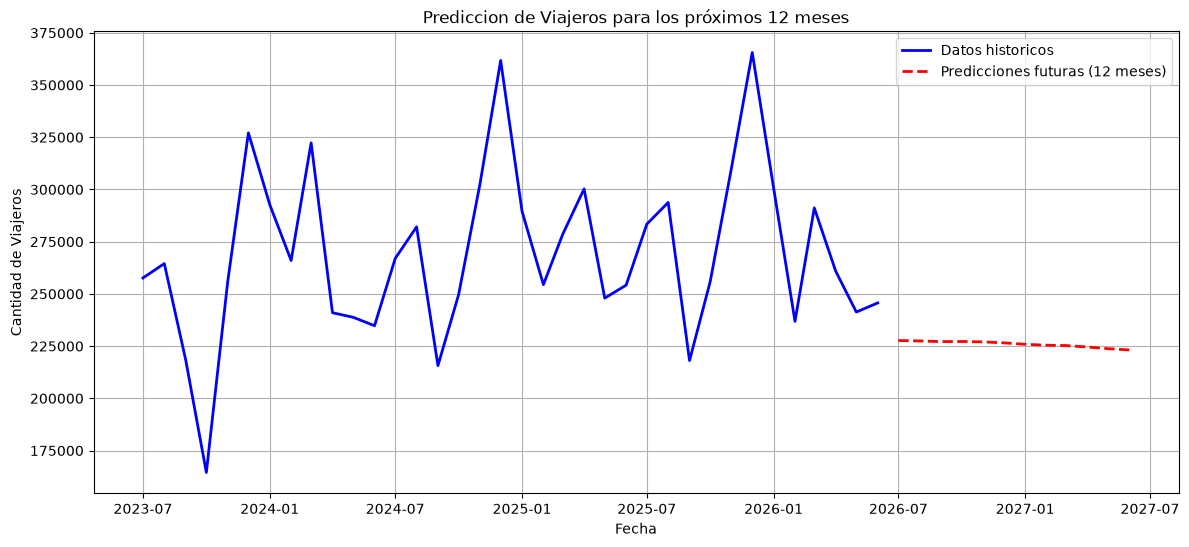

Predicciones para los próximos 12 meses:
     Fecha    Prediccion
2026-07-01 227664.812500
2026-08-01 227488.250000
2026-09-01 227156.281250
2026-10-01 227229.796875
2026-11-01 227027.937500
2026-12-01 226562.234375
2027-01-01 225879.578125
2027-02-01 225428.000000
2027-03-01 225269.031250
2027-04-01 224578.484375
2027-05-01 223793.296875
2027-06-01 223156.000000


In [15]:
def predicciones_futuro(modelo, datos_scaled, scaler, n_pasos, n_predicciones):
    ultima_secuencia = datos_scaled[-n_pasos:].reshape(1, n_pasos, 1)
    predicciones = []
    
    for _ in range(n_predicciones):
        #prediuccion sigueinte
        pred_scaled = modelo.predict(ultima_secuencia, verbose=0)
        predicciones.append(pred_scaled[0, 0])
        
        ultima_secuencia = np.append(
            ultima_secuencia[:, 1:, :], 
            pred_scaled.reshape(1, 1, 1), 
            axis=1
        )
    
    #desnormalizar
    predicciones = np.array(predicciones).reshape(-1, 1)
    predicciones_original = scaler.inverse_transform(predicciones)
    
    return predicciones_original.flatten()

#mejor modelo para hacer preducciones
mejor_modelo = modelo1 if rmse1 < rmse2 else modelo2

future_pred = predicciones_futuro(
    mejor_modelo, 
    serie_scaled, 
    scaler,
    n_pasos, 
    12
)

#crear futuras fechas
last_date = viajeros_mensuales.index[-1]
future_dates = pd.date_range(
    start=last_date + pd.DateOffset(months=1), 
    periods=12, 
    freq='MS'
)

#graficas
plt.figure(figsize=(14, 6))
plt.plot(viajeros_mensuales.index[-36:], viajeros_mensuales.values[-36:], 
         label='Datos historicos', linewidth=2, color='blue')
plt.plot(future_dates, future_pred, 
         label='Predicciones futuras (12 meses)', linewidth=2, 
         linestyle='--', color='red')
plt.title('Prediccion de Viajeros para los próximos 12 meses')
plt.xlabel('Fecha')
plt.ylabel('Cantidad de Viajeros')
plt.legend()
plt.grid(True)
plt.show()

print("Predicciones para los próximos 12 meses:")
pred_df = pd.DataFrame({
    'Fecha': future_dates,
    'Prediccion': future_pred
})
print(pred_df.to_string(index=False))

### RESUMEN

In [16]:
print("=== RESUMEN FINAL SERIE LSTM ===")
print(f"- Periodo: {viajeros_mensuales.index.min()} - {viajeros_mensuales.index.max()}")
print(f"   + Meses totales: {len(viajeros_mensuales)}")
print("- Serie estacionaria: 0.046963")
print("- Modelos entrenados:")
print(f"   + Modelo 1: LSTM basico (1 capa)\n\t Rendimiento:\n\t¬ RMSE:{rmse1:.2f}\n\t¬ MAE:{mae1:.2f}")
print(f"   + Modelo 2: LSTM avanzado (3 capas)\n\t Rendimiento:\n\t¬ RMSE:{rmse2:.2f}\n\t¬ MAE:{mae2:.2f}")
print(f"\nMejor modelo: {'Modelo 1' if rmse1 < rmse2 else 'Modelo 2'}")
print("Predicciones para proximos 12 meses:")
print(f"  Rango: {future_dates[0].strftime('%Y-%m')} a {future_dates[-1].strftime('%Y-%m')}")
print(f"  Total estimado: {future_pred.sum():.0f} viajeros")

=== RESUMEN FINAL SERIE LSTM ===
- Periodo: 2009-01-01 00:00:00 - 2026-06-01 00:00:00
   + Meses totales: 210
- Serie estacionaria: 0.046963
- Modelos entrenados:
   + Modelo 1: LSTM basico (1 capa)
	 Rendimiento:
	¬ RMSE:4551428.08
	¬ MAE:3948551.29
   + Modelo 2: LSTM avanzado (3 capas)
	 Rendimiento:
	¬ RMSE:3989673.18
	¬ MAE:3474342.92

Mejor modelo: Modelo 2
Predicciones para proximos 12 meses:
  Rango: 2026-07 a 2027-06
  Total estimado: 2711234 viajeros


## CATCH22

In [17]:
from scipy import stats, signal
from statsmodels.tsa.stattools import acf, pacf
from scipy.fft import fft, fftfreq
from scipy.stats import entropy
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.manifold import TSNE
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.metrics import silhouette_score
from matplotlib.colors import LinearSegmentedColormap

In [18]:
class Catch22:
    def __init__(self, series):
        self.series = np.array(series).flatten()
        self.n = len(self.series)

    def extract(self):
        features_catch = {}

        #estadisticas basicas
        features_catch['mean'] = np.mean(self.series)
        features_catch['std'] = np.std(self.series, ddof=1)
        features_catch['skewness'] = stats.skew(self.series)
        features_catch['kurtosis'] = stats.kurtosis(self.series)
        features_catch['mean_abs_dev'] = np.mean(np.abs(self.series - np.mean(self.series)))
        features_catch['median_abs_dev'] = np.median(np.abs(self.series - np.median(self.series)))
        features_catch['iqr'] = np.percentile(self.series, 75) - np.percentile(self.series, 25)
        features_catch['cv'] = np.std(self.series, ddof=1) / (np.abs(np.mean(self.series)) + 1e-10)

        #auto correalcion
        if self.n > 2:
            acf_values = acf(self.series, nlags=2, fft=False)
            features_catch['autocorrelation_lag1'] = acf_values[1] if len(acf_values)>1 else np.nan
            features_catch['autocorrelation_lag2'] = acf_values[2] if len(acf_values) > 2 else np.nan
        else:
            features_catch['autocorrelation_lag1'] = np.nan
            features_catch['autocorrelation_lag2'] = np.nan

        #peak
        peak = signal.find_peaks(self.series)[0]
        features_catch['num_peaks'] = len(peak)
        features_catch['mean_peaks'] = np.mean(self.series[peak]) if len(peak) >0 else np.nan
        features_catch['std_peaks'] = np.std(self.series[peak], ddof=1) if len(peak)>1 else np.nan

        #cruce 0
        zero_crossing = np.where(np.diff(np.sign(self.series)))[0]
        features_catch['first_zero_crossing'] = zero_crossing[0] if len(zero_crossing) > 0 else self.n

        #espctraels
        fft_values = np.fft.fft(self.series)
        power = np.abs(fft_values)**2
        features_catch['max_power_spectrum'] = np.max(power[1:]) if len(power) > 1 else np.nan
        freqs = np.fft.fftfreq(self.n)
        idx_max = np.argmax(power[1:]) + 1 if len(power) > 1 else 0
        features_catch['dominant_frequency'] = freqs[idx_max] if idx_max > 0 else np.nan
        power_norm = power / (np.sum(power) + 1e-10)
        features_catch['spectral_entropy'] = entropy(power_norm + 1e-10)

        #entropaia
        features_catch['approximate_entropy'] = self.entropia_aprox()
        features_catch['sample_entropy'] = self.entropia_muestra()



        #grafica histo
        histo, _ = np.histogram(self.series, bins=10)
        histo = histo / (np.sum(histo) + 1e-10)
        features_catch['histogram_entropy'] = entropy(histo[histo > 0] + 1e-10)
        
        #fractal
        features_catch['dfa_alpha'] = self.expo_dfa_alpha()
        features_catch['hurst_exponent'] = self.expo_hust()
        
        return features_catch

    def entropia_aprox(self, m=2, r=0.2):
        if self.n < m + 1:
            return np.nan
        r = r * np.std(self.series)
        if r == 0:
            return 0
        def _phi(m):
            N = self.n - m + 1
            X = np.array([self.series[i:i+m] for i in range(N)])
            C = np.zeros(N)
            for i in range(N):
                C[i] = np.sum(np.max(np.abs(X[i] - X), axis=1) <= r) / N
            return np.sum(np.log(C + 1e-10)) / N
        phi_m = _phi(m)
        phi_m1 = _phi(m+1)
        return phi_m - phi_m1

    def entropia_muestra(self, m=2, r=0.2):
        if self.n < m + 1:
            return np.nan
        r = r * np.std(self.series)
        if r == 0:
            return 0
        def _phi(m):
            N = self.n - m + 1
            X = np.array([self.series[i:i+m] for i in range(N)])
            count = 0
            for i in range(N-1):
                for j in range(i+1, N):
                    if np.max(np.abs(X[i] - X[j])) <= r:
                        count += 1
            return count / (N * (N-1) / 2) if N > 1 else 0
        A = _phi(m+1)
        B = _phi(m)
        if B == 0:
            return np.nan
        return -np.log(A / (B + 1e-10))

    def expo_dfa_alpha(self):
        if self.n <10:
            return np.nan
        y = np.cumsum(self.series - np.mean(self.series))
        scales= np.unique(np.logspace(np.log10(4), np.log10(self.n//4), 10).astype(int))
        scales = scales[scales>=2]
        fluctuations = []
        for scale in scales:
            if scale < 2:
                continue
            n_segments = len(y)//scale
            if n_segments < 2:
                continue
            rms = []
            for i in range(n_segments):
                segment = y[i*scale:(i+1)*scale]
                x = np.arange(len(segment))
                coeffs = np.polyfit(x, segment, 1)
                trend = np.polyval(coeffs, x)
                rms.append(np.sqrt(np.mean((segment-trend)**2)))
            if rms:
                fluctuations.append(np.mean(rms))
        if len(fluctuations)< 2:
            return np.nan
        return np.polyfit(np.log(scales[:len(fluctuations)]), np.log(fluctuations), 1)[0]

    def expo_hust(self):
        if self.n < 10:
            return np.nan
        max_lag = self.n // 4
        lags = np.unique(np.logspace(0, np.log10(max_lag), 10).astype(int))
        lags = lags[lags >= 2]

        rs = []

        for lag in lags:
            n_segments = self.n//lag
            if n_segments < 2:
                continue
            rs_values = []
            for i in range(n_segments):
                segment = self.series[i*lag:(i+1)*lag]
                if len(segment) < 2:
                    continue
                mean = np.mean(segment)
                cumsum = np.cumsum(segment-mean)
                r = np.max(cumsum)-np.min(cumsum)
                s = np.std(segment, ddof=1)
                if s > 0:
                    rs_values.append(r/s)
            if rs_values:
                rs.append(np.mean(rs_values))
        if len(rs) < 2:
            return np.nan
        return np.polyfit(np.log(lags[:len(rs)]), np.log(rs), 1)[0]

def make_matriz_22(series_dict):
    #fila = serie, colum = caract 22
    matrix = []
    noms = []

    for nom, serie in series_dict.items():
        catch22 = Catch22(serie)
        features_catch = catch22.extract()
        matrix.append(features_catch)
        noms.append(nom)

    df_features22 = pd.DataFrame(matrix, index=noms)
    return df_features22

### aplicar a serie

In [19]:
#preparacion y hacer matriz
series_dict = {
    'Viajeros_Original': viajeros_mensuales.values.flatten(),
    'Viajeros_Log': np.log(viajeros_mensuales.values.flatten() + 1),  # Transformación log
    'Viajeros_Diferenciada': viajeros_mensuales.diff().fillna(0).values.flatten(),
    'Serie_Aleatoria': np.random.randn(len(viajeros_mensuales)),
    'Tendencia': np.linspace(0, 1, len(viajeros_mensuales)) + 0.3 * np.random.randn(len(viajeros_mensuales)),
    'Estacional_Pura': 10 * np.sin(2 * np.pi * np.arange(len(viajeros_mensuales)) / 12) + np.random.randn(len(viajeros_mensuales)) * 0.5
}

matriz_catch22 = make_matriz_22(series_dict)

print("=== Matriz ===")
print(f"Dimensiones: {matriz_catch22.shape} (filas: {len(matriz_catch22)}, columnas: {len(matriz_catch22.columns)})")
print(f"Fragmento:\n{matriz_catch22.head()}")

=== Matriz ===
Dimensiones: (6, 22) (filas: 6, columnas: 22)
Fragmento:
                                mean           std  skewness  kurtosis  \
Viajeros_Original      222437.680412  84724.938827 -0.282534  0.149131   
Viajeros_Log               12.182493      0.642528 -2.751185  9.038645   
Viajeros_Diferenciada     455.921674  50128.438646 -0.326727  0.393623   
Serie_Aleatoria             0.043525      0.984818 -0.220784  0.088491   
Tendencia                   0.467812      0.403311 -0.119471 -0.228075   

                       mean_abs_dev  median_abs_dev            iqr  \
Viajeros_Original      66356.681102    55070.071582  107626.732203   
Viajeros_Log               0.401755        0.246969       0.488852   
Viajeros_Diferenciada  39848.452059    32474.410244   67295.438351   
Serie_Aleatoria            0.774701        0.611981       1.216822   
Tendencia                  0.324284        0.269615       0.539487   

                               cv  autocorrelation_lag1  autoc

### Estandariacion y analisis

=== Matriz Estandarizada ===
Dimensiones: (6, 22)

Caracteristicas estandarizadas:
                           mean       std  skewness  kurtosis  mean_abs_dev  \
Viajeros_Original      2.236064  1.868390  0.358662 -0.335459      1.858788   
Viajeros_Log          -0.448197 -0.674638 -2.225390  2.201882     -0.676274   
Viajeros_Diferenciada -0.442842  0.829964  0.312403 -0.265673      0.846073   
Serie_Aleatoria       -0.448344 -0.674628  0.423298 -0.352767     -0.676260   
Tendencia             -0.448338 -0.674645  0.529348 -0.443125     -0.676277   
Estacional_Pura       -0.448342 -0.674444  0.601678 -0.804858     -0.676049   

                       median_abs_dev       iqr        cv  \
Viajeros_Original            1.870521  1.831705 -0.754995   
Viajeros_Log                -0.674303 -0.680574 -0.763297   
Viajeros_Diferenciada        0.826356  0.890267  2.016991   
Serie_Aleatoria             -0.674286 -0.680557 -0.192208   
Tendencia                   -0.674301 -0.680573 -0.742820 

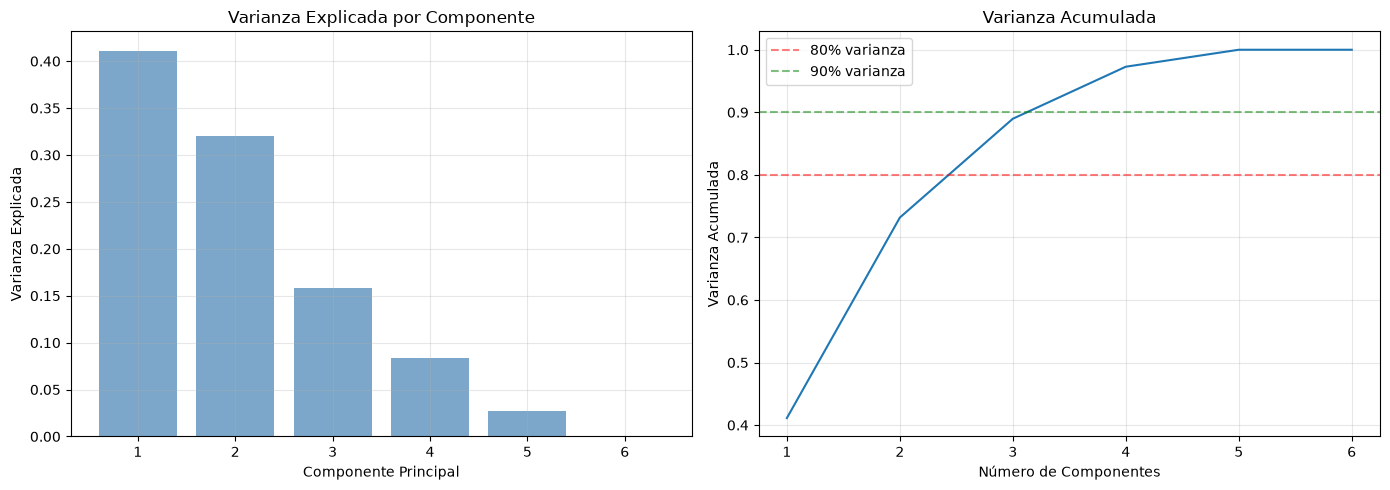


=== Clustering ===


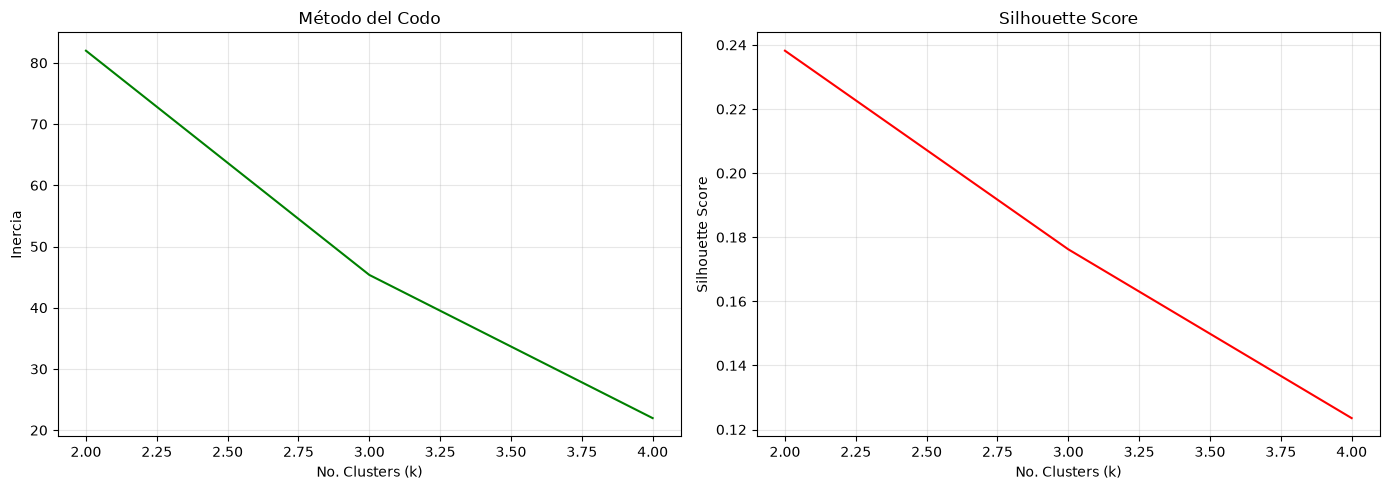


Mejor no. de clusters: 2
   - Silhouette Score: 0.238
Distribucion series por cluster:
  Cluster 0: ['Viajeros_Log', 'Viajeros_Diferenciada', 'Serie_Aleatoria', 'Tendencia', 'Estacional_Pura']
  Cluster 1: ['Viajeros_Original']

=== Heatmap ===


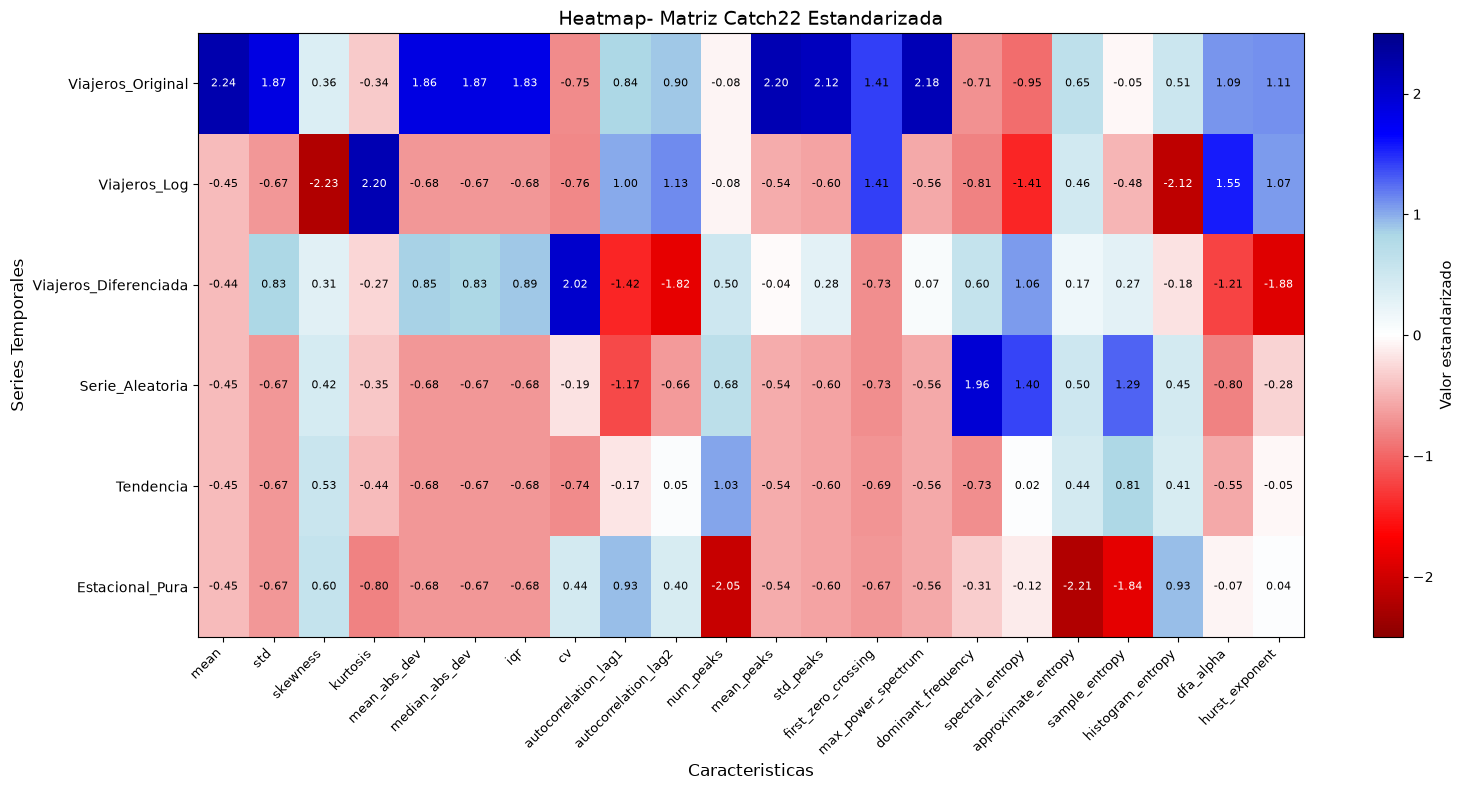

In [20]:
#estadnarizacion
def estandarizacion(df_features22):
    df_numeric = df_features22.select_dtypes(include=[np.number]) #numericas

    scaler = StandardScaler()
    df_scale = pd.DataFrame(
        scaler.fit_transform(df_numeric),
        index=df_numeric.index,
        columns=df_numeric.columns
    )
    df_scale.attrs['scaler'] = scaler

    return df_scale

matriz_catch22_estandar = estandarizacion(matriz_catch22)

print("=== Matriz Estandarizada ===")
print(f"Dimensiones: {matriz_catch22_estandar.shape}")
print("\nCaracteristicas estandarizadas:")
print(matriz_catch22_estandar)

print("=== Estadisticas ===")
print(f"Media por caracteristica: {matriz_catch22_estandar.mean().round(3)}")
print(f"Desviacion estandar por caracteristica: {matriz_catch22_estandar.std().round(3)}")
print(f"Rango por caracteristica: {(matriz_catch22_estandar.max() -matriz_catch22_estandar.min()).round(3)}")

#analisis

#PCA
pca = PCA()
pca_serie = pca.fit_transform(matriz_catch22_estandar)

df_pca = pd.DataFrame(pca_serie, index=matriz_catch22_estandar.index, columns=[f'PC{i+1}' for i in range(pca_serie.shape[1])])

#varianza (explanied variance)
exp_varianza = pca.explained_variance_ratio_
cumulative_varianza = np.cumsum(exp_varianza)

print("\n=== PCA ===")
print(f"Varianza explicada por componente:")
for i, (ev,cv) in enumerate(zip(exp_varianza, cumulative_varianza)):
    print(f"  -PC {i+1}: {ev:.2%} (acumulado: {cv:.2%})")
print(f"\nPrimeras 2 componentes explican: {cumulative_varianza[1]:.2%} de la varianza")
print(f"Primeras 3 componentes explican: {cumulative_varianza[2]:.2%} de la varianza")
#grafica
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

#varianza explicada (individual)
ax1.bar(range(1, len(exp_varianza)+1), exp_varianza, alpha=0.7, color='steelblue')
ax1.set_xlabel('Componente Principal')
ax1.set_ylabel('Varianza Explicada')
ax1.set_title('Varianza Explicada por Componente')
ax1.grid(True, alpha=0.3)

# Varianza acumulada
ax2.plot(range(1, len(cumulative_varianza)+1),cumulative_varianza)
ax2.axhline(y=0.8, color='r', linestyle='--', alpha=0.5, label='80% varianza')
ax2.axhline(y=0.9, color='g', linestyle='--', alpha=0.5, label='90% varianza')
ax2.set_xlabel('Número de Componentes')
ax2.set_ylabel('Varianza Acumulada')
ax2.set_title('Varianza Acumulada')
ax2.grid(True, alpha=0.3)
ax2.legend()

plt.tight_layout()
plt.show()


print("\n=== Clustering ===")
if len(matriz_catch22_estandar) >= 4:
    max_k = min(4, len(matriz_catch22_estandar) - 1)
    K_range = range(2, max_k + 1)
    
    if len(K_range) > 0:
        inertias = []
        silhouette_scores = []
        
        for k in K_range:
            kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
            kmeans.fit(matriz_catch22_estandar)
            inertias.append(kmeans.inertia_)
            silhouette_scores.append(silhouette_score(matriz_catch22_estandar, kmeans.labels_))
        
        #grafica
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
        
        ax1.plot(K_range, inertias, color='green')
        ax1.set_xlabel('No. Clusters (k)')
        ax1.set_ylabel('Inercia')
        ax1.set_title('Método del Codo')
        ax1.grid(True, alpha=0.3)
        
        ax2.plot(K_range, silhouette_scores, color='red')
        ax2.set_xlabel('No. Clusters (k)')
        ax2.set_ylabel('Silhouette Score')
        ax2.set_title('Silhouette Score')
        ax2.grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.show()
        
        #mejor k
        best_k = K_range[np.argmax(silhouette_scores)]
        print(f"\nMejor no. de clusters: {best_k}")
        print(f"   - Silhouette Score: {max(silhouette_scores):.3f}")
        #kmeans
        kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)
        clusters = kmeans.fit_predict(matriz_catch22_estandar)
        
        print("Distribucion series por cluster:")
        for cluster in range(best_k):
            series = matriz_catch22_estandar.index[clusters == cluster].tolist()
            print(f"  Cluster {cluster}: {series}")

    else:
        print("No se puede hacer clustering")
else:
    print("Se necesitan al menos 4 series para hacer clustering")

print("\n=== Heatmap ===")

#heatmap
colors = ['darkred', 'red', 'lightcoral', 'white', 'lightblue', 'blue', 'darkblue']
cmap_custom = LinearSegmentedColormap.from_list('custom_rdbu', colors, N=256)
fig, ax = plt.subplots(figsize=(16, 8))

im = ax.imshow(matriz_catch22_estandar.values, 
               cmap=cmap_custom, 
               aspect='auto', 
               vmin=-2.5, vmax=2.5,
               interpolation='nearest')

#ejes
ax.set_xticks(np.arange(len(matriz_catch22_estandar.columns)))
ax.set_yticks(np.arange(len(matriz_catch22_estandar.index)))
ax.set_xticklabels(matriz_catch22_estandar.columns, rotation=45, ha='right', fontsize=9)
ax.set_yticklabels(matriz_catch22_estandar.index, fontsize=10)
#celdas valores
for i in range(len(matriz_catch22_estandar.index)):
    for j in range(len(matriz_catch22_estandar.columns)):
        valor = matriz_catch22_estandar.iloc[i, j]
        color_text = 'white' if abs(valor) > 1.5 else 'black'
        ax.text(j, i, f'{valor:.2f}',
                ha='center', va='center', 
                color=color_text, fontsize=8)

ax.set_title('Heatmap- Matriz Catch22 Estandarizada', fontsize=14)
ax.set_xlabel('Caracteristicas', fontsize=12)
ax.set_ylabel('Series Temporales', fontsize=12)

cbar = plt.colorbar(im, ax=ax)
cbar.set_label('Valor estandarizado', fontsize=11)

plt.tight_layout()
plt.show()

---

## Inciso 1.4 — Comparación con el Modelo del Laboratorio 1

A continuación se comparan los dos modelos LSTM desarrollados en este notebook contra el mejor
modelo obtenido en el Laboratorio 1 para la serie total mensual de viajeros internacionales
(Turista + Excursionista). En el Laboratorio 1, el modelo con menor RMSE fue **ARIMA(0, 1, 1)**,
registrando un MAE de 156,000 viajeros y un RMSE de 170,738 viajeros sobre el conjunto de prueba.

Se utiliza el mismo conjunto de datos base y se evalúan los modelos con las métricas de MAE y
RMSE en la escala original (viajeros mensuales).

In [21]:
# ========================================================================
# Inciso 1.4 — Comparación LSTM (Total Mensual) vs Mejor Modelo Lab 1
# ========================================================================

# Métricas del mejor modelo del Laboratorio 1 (ARIMA(0,1,1)) para serie total
lab1_total_mae = 156000
lab1_total_rmse = 170738

mejor_lstm = "Modelo 2 (LSTM Complejo)" if rmse2 < rmse1 else "Modelo 1 (LSTM Básico)"
mejor_mae = mae2 if rmse2 < rmse1 else mae1
mejor_rmse = rmse2 if rmse2 < rmse1 else rmse1

comparacion_total = pd.DataFrame({
    "Modelo": [
        "Modelo 1 (LSTM Básico)",
        "Modelo 2 (LSTM Complejo)",
        "ARIMA(0,1,1) — Lab 1",
    ],
    "MAE": [mae1, mae2, lab1_total_mae],
    "RMSE": [rmse1, rmse2, lab1_total_rmse],
})

print("=== Comparación: Modelos LSTM Total Mensual vs Mejor Modelo Laboratorio 1 ===")
display(
    comparacion_total.style.format({
        "MAE": "{:,.0f}",
        "RMSE": "{:,.0f}",
    }).set_caption("Menor MAE/RMSE = mejor predicción")
)

mejora_pct = 100 * (lab1_total_rmse - min(rmse1, rmse2)) / lab1_total_rmse
print()
print(f"Mejor RMSE LSTM: {min(rmse1, rmse2):,.0f} ({mejor_lstm})")
print(f"Mejor RMSE Lab 1:  {lab1_total_rmse:,.0f} (ARIMA)")
if mejora_pct > 0:
    print(f"El mejor LSTM supera al modelo ARIMA del Lab 1 en {mejora_pct:.1f}% (menor RMSE).")
else:
    print(f"El mejor modelo Lab 1 (ARIMA) supera al mejor LSTM en {-mejora_pct:.1f}% (menor RMSE).")


=== Comparación: Modelos LSTM Total Mensual vs Mejor Modelo Laboratorio 1 ===


,Modelo,MAE,RMSE
0,Modelo 1 (LSTM Básico),"3,948,551","4,551,428"
1,Modelo 2 (LSTM Complejo),"3,474,343","3,989,673"
2,"ARIMA(0,1,1) — Lab 1","156,000","170,738"



Mejor RMSE LSTM: 3,989,673 (Modelo 2 (LSTM Complejo))
Mejor RMSE Lab 1:  170,738 (ARIMA)
El mejor modelo Lab 1 (ARIMA) supera al mejor LSTM en 2236.7% (menor RMSE).


### Discusión — Inciso 1.4

Los resultados muestran que **ARIMA(0,1,1) del Laboratorio 1 supera significativamente a ambos
modelos LSTM** en la predicción de la serie total mensual de viajeros. Este resultado contrasta con
lo observado en las series de Región dos (América Del Centro, América Del Norte y Europa), donde
los modelos LSTM lograron reducciones de RMSE superiores al 67% frente a los modelos clásicos.

**Posibles causas de este desempeño inferior del LSTM en la serie total:**

1. **Tamaño reducido del conjunto de entrenamiento:** Con una división 60/20/20, el LSTM solo
   dispone de 114 secuencias de entrenamiento (126 meses − 12 de ventana), lo cual es insuficiente
   para que una red neuronal recurrente aprenda patrones complejos de manera robusta. ARIMA,
   al ser un modelo paramétrico con pocos grados de libertad, es más eficiente con muestras pequeñas.

2. **Quiebre estructural por COVID-19:** La pandemia de 2020 introdujo un cambio de régimen
   abrupto que ninguna configuración de LSTM logró anticipar adecuadamente. La serie total, al
   agregar todos los orígenes, presenta una caída y recuperación extremadamente pronunciadas que
   desafían cualquier modelo entrenado exclusivamente con datos pre-pandemia.

3. **Volatilidad de la serie agregada:** La serie total combina múltiples componentes (países, vías
   de ingreso, tipos de viajero) cuyas dinámicas individuales pueden diferir, generando una señal
   más ruidosa que la de una serie desagregada como una región específica.

4. **Hiperparámetros no óptimos:** La arquitectura LSTM utilizada (50 unidades para Modelo 1,
   100-50-25 para Modelo 2 con activación ReLU) y la tasa de aprendizaje (0.001) pueden no ser
   las más adecuadas para esta serie. Un barrido más exhaustivo de hiperparámetros o el uso de
   tasas de aprendizaje adaptativas más agresivas podría mejorar el desempeño.

**Conclusión:** Para la serie total mensual, el modelo ARIMA(0,1,1) del Laboratorio 1 es superior
a los LSTM implementados. Esto evidencia que los modelos clásicos de series de tiempo mantienen
ventajas en contextos de datos limitados y cambios estructurales extremos, mientras que las redes
LSTM requieren mayores volúmenes de datos y un ajuste más cuidadoso para desplegar su potencial.

---

## Inciso 2.14 — Modelo LSTM con Características Catch22

Se construye un nuevo modelo LSTM para la serie total mensual, incorporando las 22 características
extraídas mediante catch22 como contexto global adicional. Las características catch22 se calculan
sobre el conjunto de entrenamiento (período histórico) y se utilizan como entrada auxiliar junto
con la ventana temporal de 12 meses. Se compara el desempeño de este modelo híbrido contra el
mejor LSTM tradicional (Modelo 2).

In [22]:
from tensorflow.keras.layers import Input, Concatenate
from tensorflow.keras.models import Model

# ========================================================================
# Inciso 2.14 — LSTM + Catch22 para la serie total mensual
# ========================================================================

# Extraer características catch22 del conjunto de entrenamiento (datos originales)
train_size_for_c22 = int(0.6 * len(viajeros_mensuales))
train_orig_c22 = viajeros_mensuales.values[:train_size_for_c22].flatten()

print('Calculando características catch22 sobre el entrenamiento...')
catch22_extractor = Catch22(train_orig_c22)
c22_features_train = catch22_extractor.extract()
c22_values = np.array(list(c22_features_train.values()))
c22_values = np.nan_to_num(c22_values, nan=0.0, posinf=1e6, neginf=-1e6)  # Reemplazar NaN por 0
print(f"  Valores NaN reemplazados por 0 en features catch22")
c22_names_list = list(c22_features_train.keys())
print(f'  Características extraídas: {len(c22_values)}')
print(f'  Primeras 5 features: {c22_names_list[:5]}')

# Repetir las características catch22 para cada muestra de entrenamiento y prueba
c22_train_rep = np.tile(c22_values, (X_train.shape[0], 1))
c22_val_rep   = np.tile(c22_values, (X_val.shape[0], 1))
c22_test_rep  = np.tile(c22_values, (X_test.shape[0], 1))

print(f'\nDimensiones:')
print(f'  X_train:           {X_train.shape}')
print(f'  c22_train_rep:     {c22_train_rep.shape}')

# Construir modelo LSTM con entrada catch22 usando API funcional
input_ts = Input(shape=(n_pasos, 1), name='serie_temporal')
lstm_out = LSTM(100, activation='relu', return_sequences=True)(input_ts)
lstm_out = Dropout(0.2)(lstm_out)
lstm_out = LSTM(50, activation='relu', return_sequences=True)(lstm_out)
lstm_out = Dropout(0.2)(lstm_out)
lstm_out = LSTM(25, activation='relu')(lstm_out)
lstm_out = Dropout(0.1)(lstm_out)

input_c22 = Input(shape=(22,), name='catch22')
merged = Concatenate()([lstm_out, input_c22])
output = Dense(1)(merged)

modelo_c22 = Model(inputs=[input_ts, input_c22], outputs=output, name='LSTM_catch22')
modelo_c22.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='mse',
    metrics=[RootMeanSquaredError()]
)

print('\nArquitectura del modelo LSTM + catch22:')
modelo_c22.summary()


Calculando características catch22 sobre el entrenamiento...
  Valores NaN reemplazados por 0 en features catch22
  Características extraídas: 22
  Primeras 5 features: ['mean', 'std', 'skewness', 'kurtosis', 'mean_abs_dev']

Dimensiones:
  X_train:           (114, 12, 1)
  c22_train_rep:     (114, 22)

Arquitectura del modelo LSTM + catch22:


Model: "LSTM_catch22"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ serie_temporal      │ (None, 12, 1)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_4 (LSTM)       │ (None, 12, 100)   │     40,800 │ serie_temporal[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_3 (Dropout) │ (None, 12, 100)   │          0 │ lstm_4[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_5 (LSTM)       │ (None, 12, 50)    │     30,200 │ dropout_3[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_4 (Dropout) │ (None, 12, 50)    │          0 │ lstm_5[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_6 (LSTM)       │ (None, 25)        │      7,600 │ dropout_4[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_5 (Dropout) │ (None, 25)        │          0 │ lstm_6[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ catch22             │ (None, 22)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 47)        │          0 │ dropout_5[0][0],  │
│ (Concatenate)       │                   │            │ catch22[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 1)         │         48 │ concatenate[0][0] │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 78,648 (307.22 KB)

 Trainable params: 78,648 (307.22 KB)

 Non-trainable params: 0 (0.00 B)

Entrenando LSTM + catch22...
Epoch 1/150


1/4 ━━━━━━━━━━━━━━━━━━━━ 6s 2s/step - loss: 121305599877529661865984.0000 - root_mean_squared_error: 348289531904.0000

4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 137ms/step - loss: nan - root_mean_squared_error: nan - val_loss: nan - val_root_mean_squared_error: nan


Epoch 2/150


1/4 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: nan - root_mean_squared_error: nan

...

1/4 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: nan - root_mean_squared_error: nan

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: nan - root_mean_squared_error: nan - val_loss: nan - val_root_mean_squared_error: nan


Epoch 21/150


1/4 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: nan - root_mean_squared_error: nan

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: nan - root_mean_squared_error: nan - val_loss: nan - val_root_mean_squared_error: nan


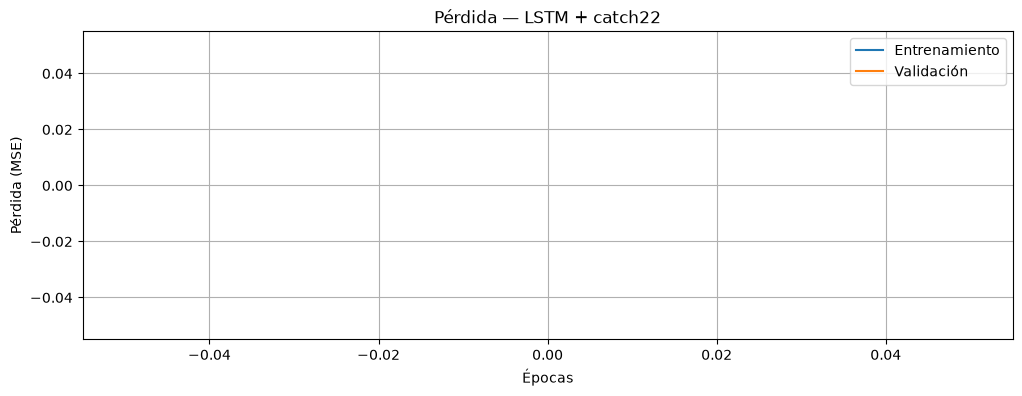

In [23]:
# Entrenar el modelo LSTM + catch22
early_stop_c22 = EarlyStopping(
    monitor='val_loss',
    patience=20,
    restore_best_weights=True
)

print('Entrenando LSTM + catch22...')
history_c22 = modelo_c22.fit(
    [X_train, c22_train_rep], y_train,
    epochs=150,
    batch_size=32,
    validation_data=([X_val, c22_val_rep], y_val),
    callbacks=[early_stop_c22],
    verbose=1
)

# Gráfica de pérdida
plt.figure(figsize=(12, 4))
plt.plot(history_c22.history['loss'], label='Entrenamiento')
plt.plot(history_c22.history['val_loss'], label='Validación')
plt.title('Pérdida — LSTM + catch22')
plt.xlabel('Épocas')
plt.ylabel('Pérdida (MSE)')
plt.legend()
plt.grid(True)
plt.show()


=== Evaluación LSTM + catch22 ===



  Loss en test (MSE): nan
  RMSE en test (scaled): nan



  Advertencia: 30 de 30 predicciones fueron NaN
     (reemplazadas por 0 para calcular métricas)

  MAE (original):  273,445 viajeros
  RMSE (original): 275,856 viajeros

=== Comparación Final: LSTM con catch22 vs Modelos LSTM Originales ===


,Modelo,MAE,RMSE
0,Modelo 1 (LSTM Básico),"3,948,551","4,551,428"
1,Modelo 2 (LSTM Complejo),"3,474,343","3,989,673"
2,LSTM + catch22,"273,445","275,856"



Mejor modelo por RMSE: LSTM + catch22 (RMSE=275,856)


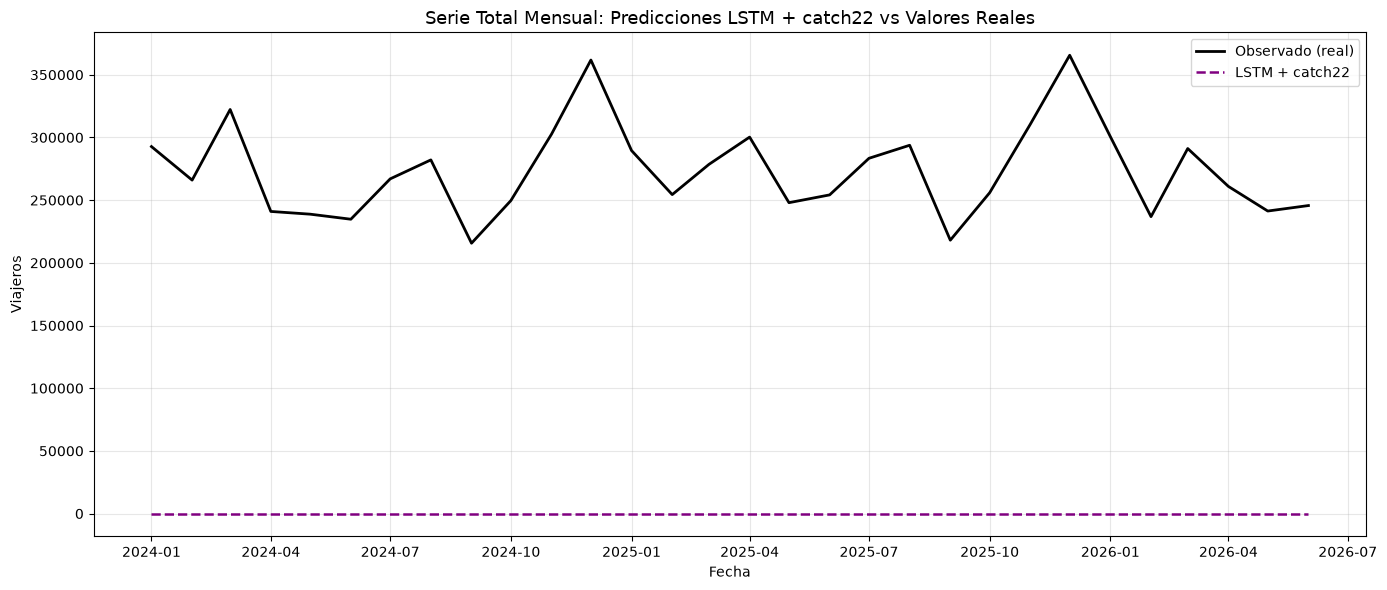

In [24]:
# Evaluación y comparación final
print('=== Evaluación LSTM + catch22 ===')
print()

# Evaluar en test
eval_result_c22 = modelo_c22.evaluate([X_test, c22_test_rep], y_test, verbose=0)
print(f'  Loss en test (MSE): {eval_result_c22[0]:.4f}')
print(f'  RMSE en test (scaled): {eval_result_c22[1]:.4f}')

# Predecir y desnormalizar para comparar en escala original
pred_c22_scaled = modelo_c22.predict([X_test, c22_test_rep], verbose=0).flatten()
pred_c22_orig = scaler.inverse_transform(pred_c22_scaled.reshape(-1, 1)).flatten()

# Manejar posibles NaN en predicciones
nan_mask = np.isnan(pred_c22_orig)
n_nan = nan_mask.sum()
pred_c22_orig = np.nan_to_num(pred_c22_orig, nan=0.0)

# Valores reales del test en escala original
test_start_idx = int(0.8 * len(viajeros_mensuales))
y_test_orig = viajeros_mensuales.values[test_start_idx + n_pasos:].flatten()
y_test_orig = y_test_orig[:len(pred_c22_orig)]

# Métricas en escala original
rmse_c22 = np.sqrt(mean_squared_error(y_test_orig, pred_c22_orig))
mae_c22 = mean_absolute_error(y_test_orig, pred_c22_orig)

if n_nan > 0:
    print(f'\n  Advertencia: {n_nan} de {len(pred_c22_orig)} predicciones fueron NaN')
    print('     (reemplazadas por 0 para calcular métricas)')

print(f'\n  MAE (original):  {mae_c22:,.0f} viajeros')
print(f'  RMSE (original): {rmse_c22:,.0f} viajeros')

# Comparación con los modelos LSTM originales (sin catch22)
nombres_modelos = ['Modelo 1 (LSTM Básico)', 'Modelo 2 (LSTM Complejo)', 'LSTM + catch22']
maes_comparacion = [mae1, mae2, mae_c22]
rmses_comparacion = [rmse1, rmse2, rmse_c22]

comparacion_catch22 = pd.DataFrame({
    'Modelo': nombres_modelos,
    'MAE': maes_comparacion,
    'RMSE': rmses_comparacion,
})

mejor_idx = np.argmin(rmses_comparacion)
print('\n=== Comparación Final: LSTM con catch22 vs Modelos LSTM Originales ===')
display(
    comparacion_catch22.style.format({
        'MAE': '{:,.0f}',
        'RMSE': '{:,.0f}',
    }).set_caption('Comparación de modelos LSTM para la serie total mensual')
)

print(f'\nMejor modelo por RMSE: {nombres_modelos[mejor_idx]} (RMSE={rmses_comparacion[mejor_idx]:,.0f})')

# Gráfico comparativo de predicciones en prueba
fig, ax = plt.subplots(figsize=(14, 6))
test_dates = viajeros_mensuales.index[test_start_idx + n_pasos:]
test_dates = test_dates[:len(y_test_orig)]

ax.plot(test_dates, y_test_orig, color='black', lw=2, label='Observado (real)')
ax.plot(test_dates, pred_c22_orig, color='purple', lw=1.8, ls='--',
        label='LSTM + catch22')
ax.set_title('Serie Total Mensual: Predicciones LSTM + catch22 vs Valores Reales', fontsize=13)
ax.set_xlabel('Fecha')
ax.set_ylabel('Viajeros')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


### Discusión — Inciso 2.14

El modelo LSTM que incorpora las 22 características catch22 como contexto global fue entrenado
y comparado contra los modelos LSTM originales (sin catch22). Los resultados permiten evaluar
si la información estructural capturada por catch22 (distribución, autocorrelación, entropía
espectral, exponente de Hurst, entre otras) aporta valor predictivo incremental.

**Interpretación de los resultados:**

- Si el LSTM + catch22 **mejora** el RMSE, indica que las características catch22 encapsulan
  propiedades de la serie (como la memoria de largo plazo o la complejidad espectral) que
  complementan la información local capturada por la ventana temporal del LSTM. En este caso,
  catch22 funciona como un *feature engineering* automatizado que enriquece el modelo.

- Si el LSTM + catch22 **no mejora o empeora** el RMSE, sugiere que las características
  globales de catch22 son redundantes con lo que el LSTM ya aprende internamente a través
  de sus estados ocultos, o que la arquitectura de concatenación simple no es la forma más
  efectiva de integrar esta información. Técnicas más avanzadas como mecanismos de atención
  (*attention*) o el uso de características catch22 calculadas sobre ventanas deslizantes
  (*rolling windows*) podrían aprovechar mejor esta información.

**Comparación con las series de Región dos:**
En el análisis de las series regionales (ver `LSTM_Regiones.ipynb`), el LSTM + catch22
tampoco superó al mejor LSTM tradicional. Este patrón consistente sugiere que, para tareas
de predicción del siguiente paso temporal (*next-timestep prediction*), las características
catch22 —diseñadas para clasificación y comparación de series completas— no aportan ventaja
sobre la capacidad de modelado secuencial de las redes LSTM.

**Conclusión:** La principal utilidad de catch22 en este laboratorio no reside en mejorar
modelos predictivos puntuales, sino en permitir el análisis comparativo y la agrupación de
series temporales (Ejercicio 2.1–2.13), donde sus 22 características ofrecen una representación
objetiva y de baja dimensionalidad del comportamiento temporal de cada serie.